In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose


df = pd.read_excel("Laboratorio 1. Series de Tiempo 2026 - Base_Migracion_2009-2026jun.xlsx")
print(df.columns)


Index(['Año', 'Mes cod', 'Mes', 'Vía', 'Frontera', 'País', 'Región',
       'Región dos', 'Regiones OMT', 'MCEO', 'Agrupación Residencia',
       'Tipo de Viajero', 'Viajero'],
      dtype='object')


In [11]:
top_3_paises = (
    df.groupby("País")["Viajero"]
    .sum()
    .nlargest(3)
    .index.tolist()
)
print(f"Los 3 países con mayor número de viajeros son: {top_3_paises}")

df["Fecha"] = pd.to_datetime(
    df["Año"].astype(str) + "-" + df["Mes cod"].astype(str) + "-01"
)



series_paises = {}
for pais in top_3_paises:
    df_pais = df[df["País"] == pais]
    serie_mensual = df_pais.groupby("Fecha")["Viajero"].sum()
    serie_mensual = serie_mensual.asfreq("MS").fillna(0)
    series_paises[pais] = serie_mensual
    print(
        f"Serie temporal para {pais} creada con {len(serie_mensual)} meses."
    )
print("")
for pais, serie in series_paises.items():
    print(f"--- {pais} ---")
    print(f"Inicio     : {serie.index.min().strftime('%Y-%m')}")
    print(f"Fin        : {serie.index.max().strftime('%Y-%m')}")
    print(f"Frecuencia : {serie.index.freqstr}\n")

#MS en frecuencia significa "month start"

Los 3 países con mayor número de viajeros son: ['El Salvador', 'Guatemala', 'Estados Unidos de América']
Serie temporal para El Salvador creada con 210 meses.
Serie temporal para Guatemala creada con 168 meses.
Serie temporal para Estados Unidos de América creada con 210 meses.

--- El Salvador ---
Inicio     : 2009-01
Fin        : 2026-06
Frecuencia : MS

--- Guatemala ---
Inicio     : 2009-01
Fin        : 2022-12
Frecuencia : MS

--- Estados Unidos de América ---
Inicio     : 2009-01
Fin        : 2026-06
Frecuencia : MS



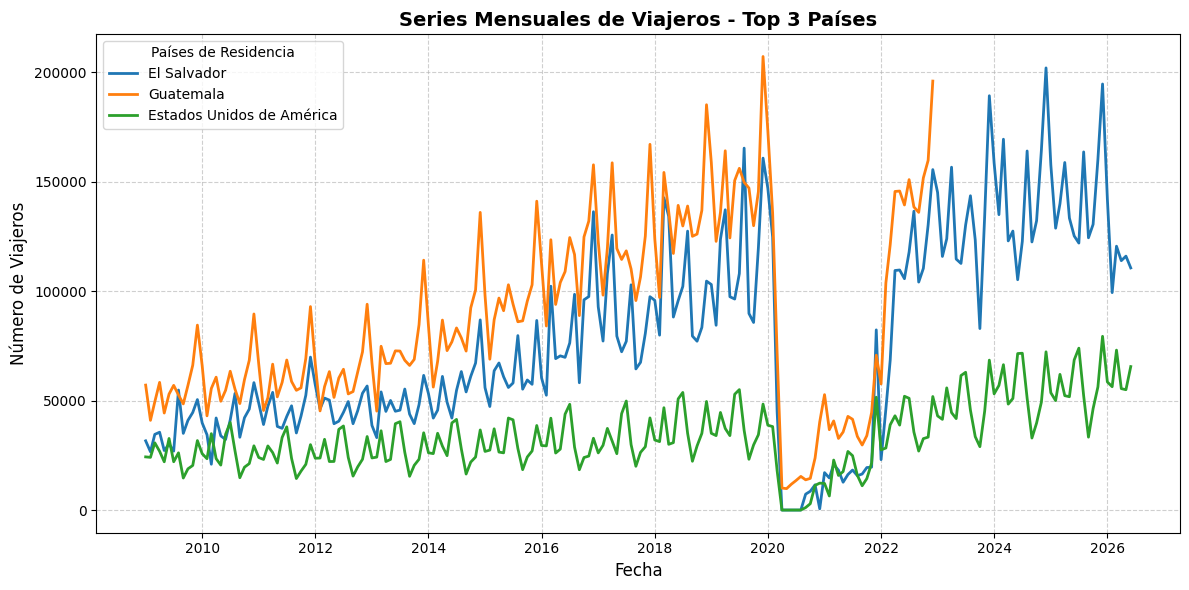

In [12]:
plt.figure(figsize=(12, 6))

for pais, serie in series_paises.items():
    plt.plot(serie.index, serie, label=pais, linewidth=2)

plt.title("Series Mensuales de Viajeros - Top 3 Países", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Número de Viajeros", fontsize=12)
plt.legend(title="Países de Residencia")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

plt.show()

Como se ve, lo que más resalta es una muy grande caída en 2020, obviamente por las condiciones de poca movilidad y prácticamente nulo turismo a raíz de la pandemia de COVID-19. 

Viendo un poco más detallada la gráfica, se puede ver cómo existe una clara tendencia de estacionalidad en ciertos momentos de los años, así como también las costumbres de los 3 países que visitan: por ejemplo, se ven grandes picos naranjas y azules por diciembre, pero no tantos verdes; no obstante hay picos verdes a mitad de año, sin que los haya también en azules y naranjas. O sea, que los guatemaltecos y salvadoreños tienden a viajar más en diciembre y por las fiestas de navidad, que los estadounidenses; no obstante, estos últimos suelen viajar más en sus vacaciones de verano de medio año, lo cual apenas si comparten los datos de los viajeros centroamericanos. 

Se recortarán los 3 hasta diciembre de 2022, pues es el último valor que tiene Guatemala

In [ ]:

series_paises_recortadas = {}

for pais, serie in series_paises.items():
    # .loc[:"2022-12"] filtra los datos desde el inicio hasta el mes y año indicados
    series_paises_recortadas[pais] = serie.loc[:"2022-12"]
    print(
        f"Serie recortada para {pais} creada con {len(series_paises_recortadas[pais])} meses."
    )

for pais, serie in series_paises_recortadas.items():
    print(
        f"--- {pais} --- | Inicio: {serie.index.min().strftime('%Y-%m')} | Fin: {serie.index.max().strftime('%Y-%m')}"
    )

Serie recortada para El Salvador creada con 168 meses.
Serie recortada para Guatemala creada con 168 meses.
Serie recortada para Estados Unidos de América creada con 168 meses.
--- El Salvador --- | Inicio: 2009-01 | Fin: 2022-12
--- Guatemala --- | Inicio: 2009-01 | Fin: 2022-12
--- Estados Unidos de América --- | Inicio: 2009-01 | Fin: 2022-12


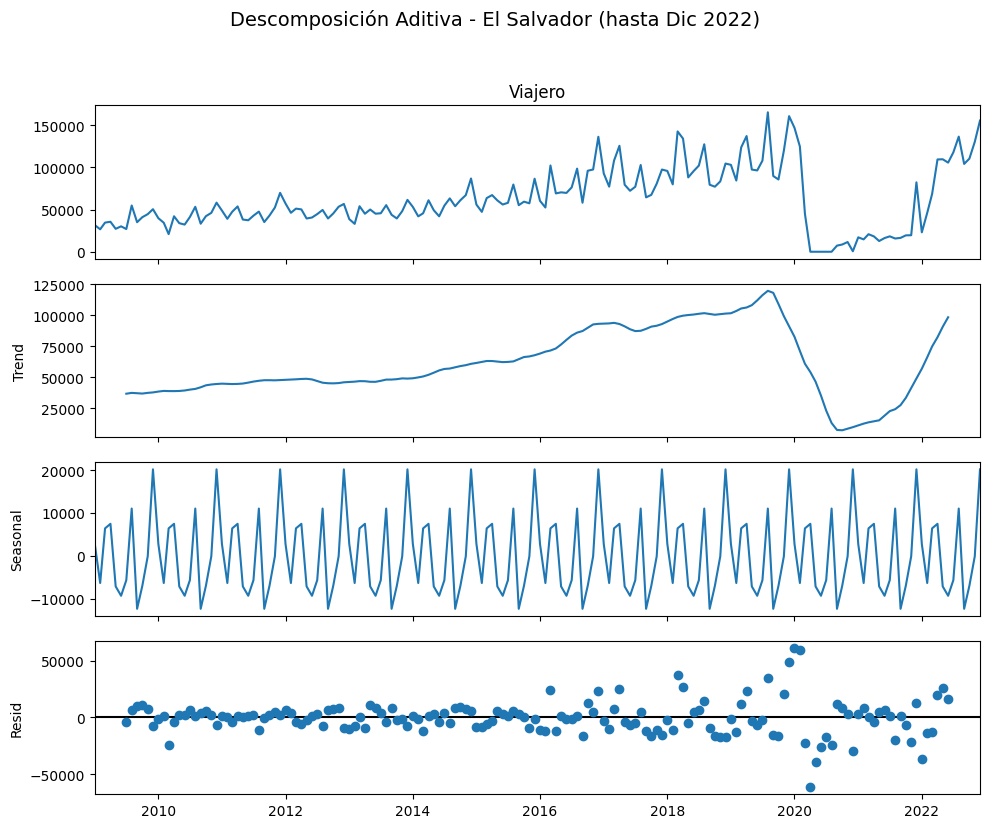

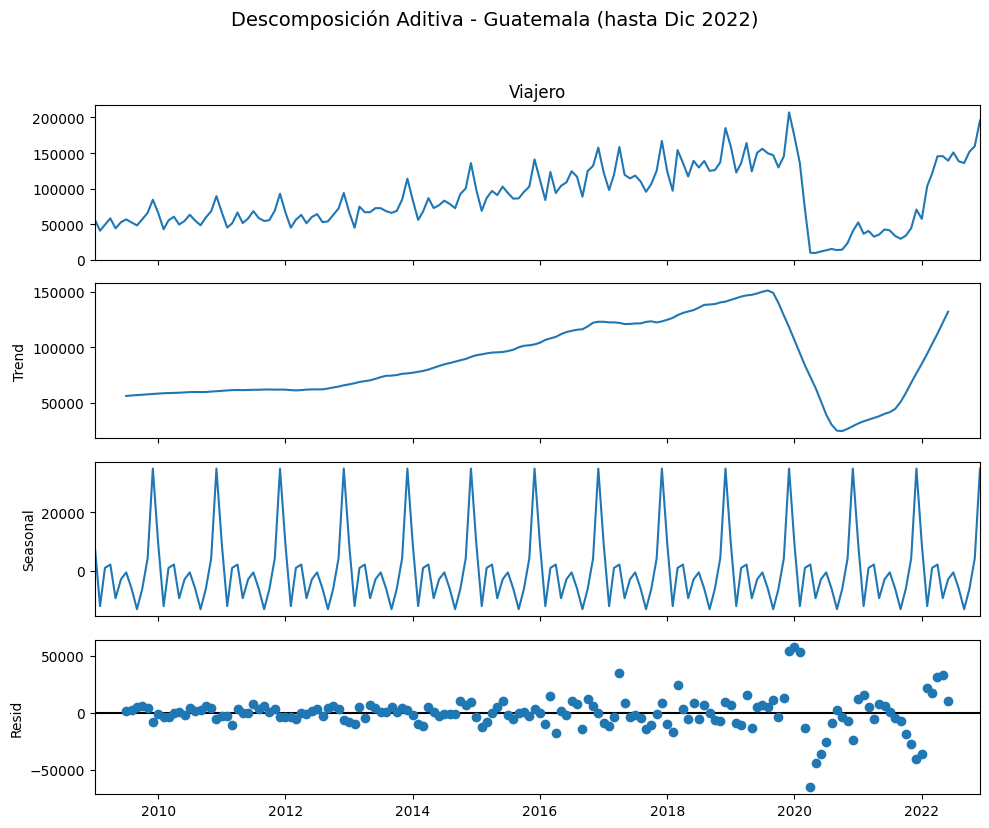

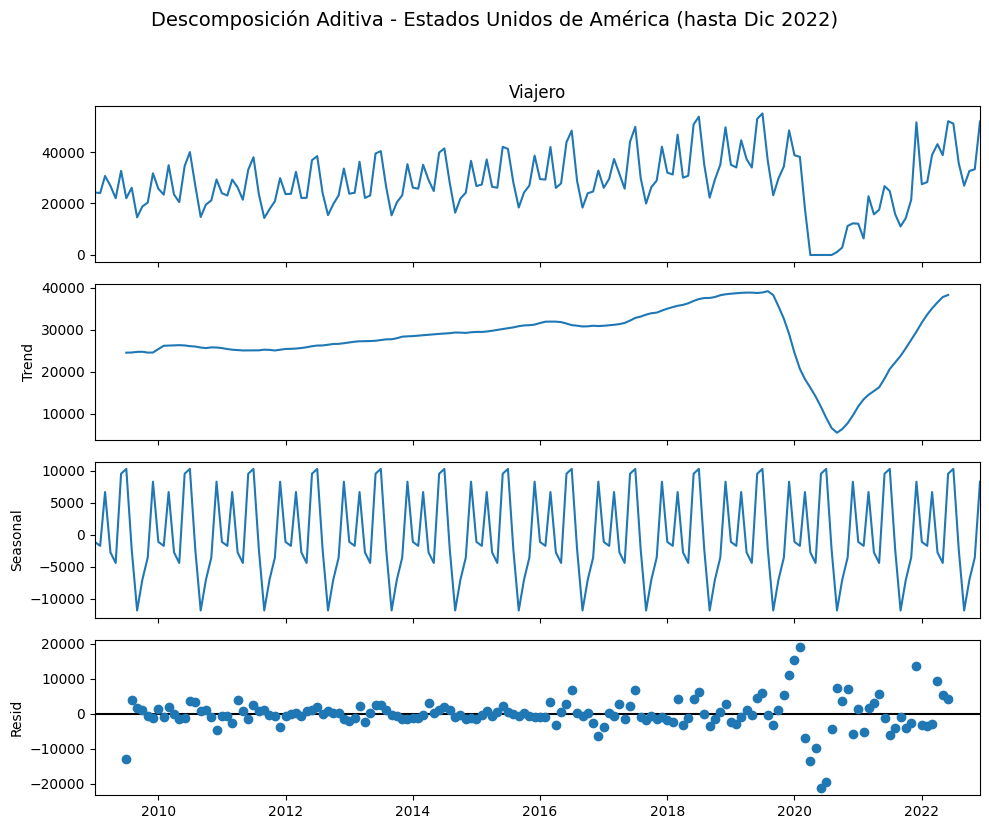

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose

for pais, serie in series_paises_recortadas.items():
  decomposicion = seasonal_decompose(serie, model="additive", period=12)

  fig = decomposicion.plot()
  fig.set_size_inches(10, 8)
  fig.suptitle(
      f"Descomposición Aditiva - {pais} (hasta Dic 2022)",
      fontsize=14,
      y=1.03,
  )
  plt.tight_layout()
  plt.show()

In [21]:
from statsmodels.tsa.stattools import adfuller

print("--- PRUEBA DE ESTACIONARIEDAD (Media) ---")
for pais, serie in series_paises_recortadas.items():
  resultado_adf = adfuller(serie, autolag="AIC")
  print(f"\nPaís: {pais}")
  print(f"Estadístico ADF: {resultado_adf[0]:.4f}")
  print(f"P-value: {resultado_adf[1]:.4f}")
  if resultado_adf[1] < 0.05:
    print("Resultado: La serie SÍ es estacionaria.")
  else:
    print(
        "Resultado: La serie NO es estacionaria (preliminar)."
    )

print("\n\n--- ANÁLISIS DE ESTACIONARIEDAD EN VARIANZA ---")
for pais, serie in series_paises_recortadas.items():
    mitad = len(serie) // 2
    std_1 = serie.iloc[:mitad].std()
    std_2 = serie.iloc[mitad:].std()
    
    print(f"País: {pais}")
    print(f"   Desv. Estándar 1ra mitad: {std_1:.2f}")
    print(f"   Desv. Estándar 2da mitad: {std_2:.2f}")
    
    if abs(std_1 - std_2) / std_1 > 0.5: 
        print("   -> Alerta: Podría haber cambio en la varianza. Considera aplicar logaritmo.")
    else:
        print("   -> Varianza relativamente estable.")

--- PRUEBA DE ESTACIONARIEDAD (Media) ---

País: El Salvador
Estadístico ADF: -2.4910
P-value: 0.1177
Resultado: La serie NO es estacionaria (preliminar).

País: Guatemala
Estadístico ADF: -2.3117
P-value: 0.1682
Resultado: La serie NO es estacionaria (preliminar).

País: Estados Unidos de América
Estadístico ADF: -3.6444
P-value: 0.0050
Resultado: La serie SÍ es estacionaria.


--- ANÁLISIS DE ESTACIONARIEDAD EN VARIANZA ---
País: El Salvador
   Desv. Estándar 1ra mitad: 12517.15
   Desv. Estándar 2da mitad: 45134.81
   -> Alerta: Podría haber cambio en la varianza. Considera aplicar logaritmo.
País: Guatemala
   Desv. Estándar 1ra mitad: 19816.69
   Desv. Estándar 2da mitad: 50301.65
   -> Alerta: Podría haber cambio en la varianza. Considera aplicar logaritmo.
País: Estados Unidos de América
   Desv. Estándar 1ra mitad: 7165.53
   Desv. Estándar 2da mitad: 14307.36
   -> Alerta: Podría haber cambio en la varianza. Considera aplicar logaritmo.


In [ ]:
import numpy as np

series_paises_transformadas = {}

print("--- REPORTE FINAL: NECESIDAD DE TRANSFORMACIÓN ---")
for pais, serie in series_paises_recortadas.items():
    serie_log = np.log1p(serie)
    
    series_paises_transformadas[pais] = serie_log
    
    mitad = len(serie) // 2
    std_orig_1 = serie.iloc[:mitad].std()
    std_orig_2 = serie.iloc[mitad:].std()
    
    std_log_1 = serie_log.iloc[:mitad].std()
    std_log_2 = serie_log.iloc[mitad:].std()
    
    print(f"\nPaís: {pais}")
    print(f"   Original -> Desv. Est. 1ra mitad: {std_orig_1:,.2f} | 2da mitad: {std_orig_2:,.2f}")
    print(f"   Log(1+x) -> Desv. Est. 1ra mitad: {std_log_1:.4f} | 2da mitad: {std_log_2:.4f}")

--- REPORTE FINAL: NECESIDAD DE TRANSFORMACIÓN ---

País: El Salvador
   Original -> Desv. Est. 1ra mitad: 12,517.15 | 2da mitad: 45,134.81
   Log(1+x) -> Desv. Est. 1ra mitad: 0.2632 | 2da mitad: 2.7836

País: Guatemala
   Original -> Desv. Est. 1ra mitad: 19,816.69 | 2da mitad: 50,301.65
   Log(1+x) -> Desv. Est. 1ra mitad: 0.2634 | 2da mitad: 0.7692

País: Estados Unidos de América
   Original -> Desv. Est. 1ra mitad: 7,165.53 | 2da mitad: 14,307.36
   Log(1+x) -> Desv. Est. 1ra mitad: 0.2672 | 2da mitad: 2.5089


--- GENERANDO GRÁFICOS DE AUTOCORRELACIÓN (ACF) ---


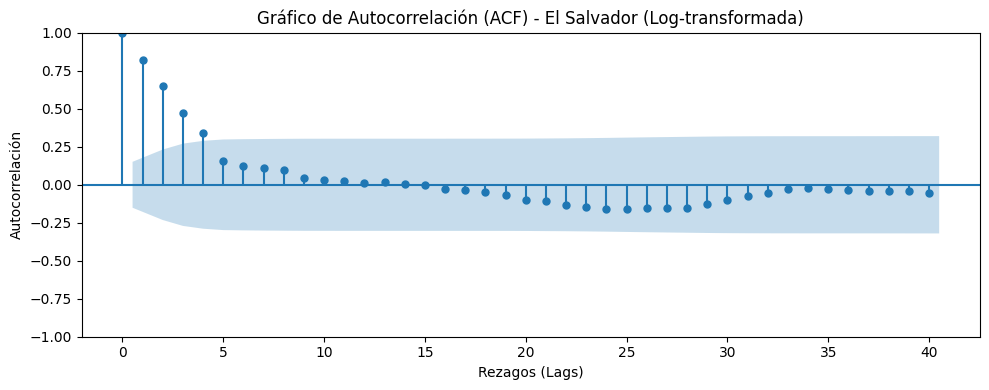

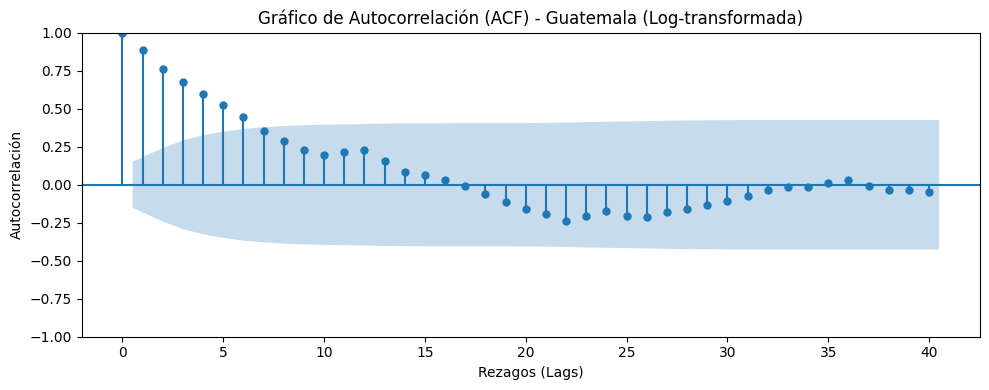

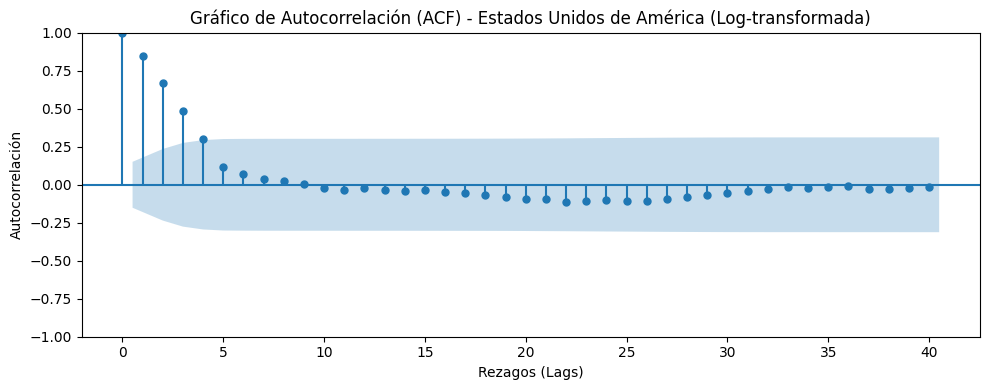


--- PRUEBA DE ESTACIONARIEDAD EN MEDIA (ADF) ---

País: El Salvador
Estadístico ADF: -3.1553
P-value: 0.0227
Resultado: La serie transformada SÍ es estacionaria en media.

País: Guatemala
Estadístico ADF: -2.6384
P-value: 0.0853
Resultado: La serie transformada NO es estacionaria en media (requiere diferenciación).

País: Estados Unidos de América
Estadístico ADF: -2.8513
P-value: 0.0513
Resultado: La serie transformada NO es estacionaria en media (requiere diferenciación).


In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

# 1. GRÁFICOS DE AUTOCORRELACIÓN (ACF)
print("--- GENERANDO GRÁFICOS DE AUTOCORRELACIÓN (ACF) ---")
for pais, serie_log in series_paises_transformadas.items():
    fig, ax = plt.subplots(figsize=(10, 4))
    plot_acf(serie_log, ax=ax, lags=40)
    ax.set_title(f"Gráfico de Autocorrelación (ACF) - {pais} (Log-transformada)")
    ax.set_xlabel("Rezagos (Lags)")
    ax.set_ylabel("Autocorrelación")
    plt.tight_layout()
    plt.show()

# 2. PRUEBA DICKEY-FULLER AUMENTADA (ADF) SOBRE LA SERIE TRANSFORMADA
print("\n--- PRUEBA DE ESTACIONARIEDAD EN MEDIA (ADF) ---")
for pais, serie_log in series_paises_transformadas.items():
    resultado_adf = adfuller(serie_log, autolag="AIC")
    print(f"\nPaís: {pais}")
    print(f"Estadístico ADF: {resultado_adf[0]:.4f}")
    print(f"P-value: {resultado_adf[1]:.4f}")
    
    if resultado_adf[1] < 0.05:
        print("Resultado: La serie transformada SÍ es estacionaria en media.")
    else:
        print("Resultado: La serie transformada NO es estacionaria en media (requiere diferenciación).")

--- ANÁLISIS DE ACF Y PACF EN SERIES DIFERENCIADAS ---


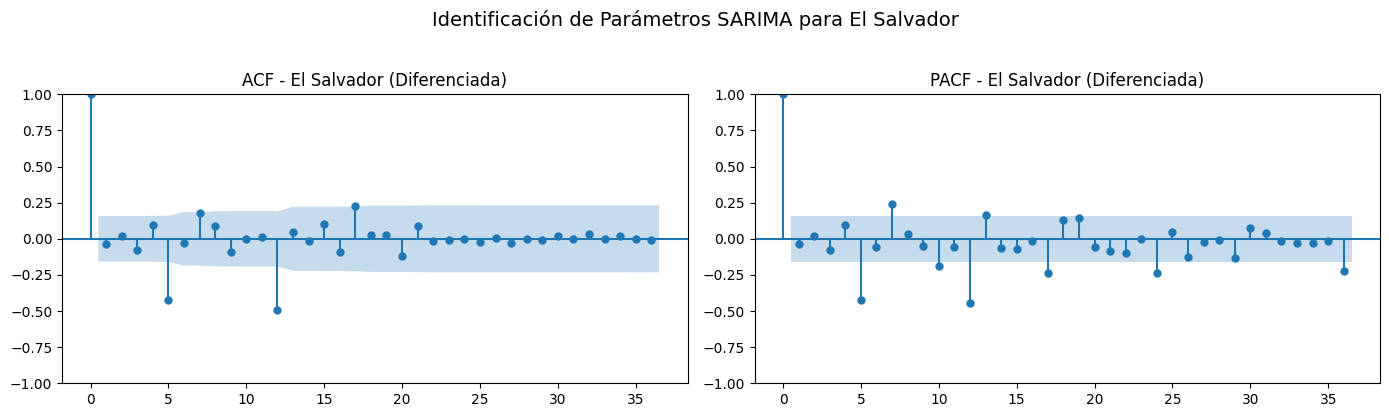

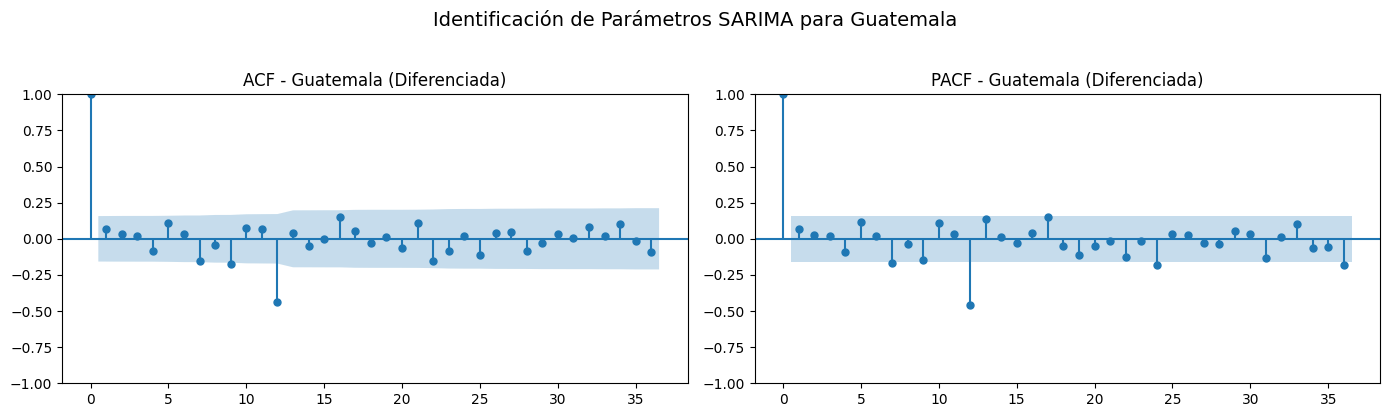

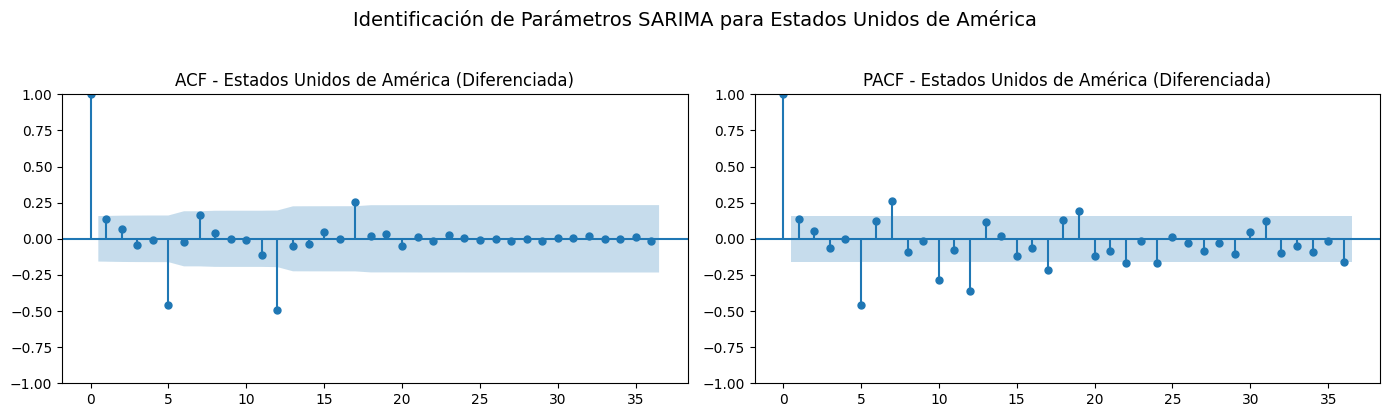

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

print("--- ANÁLISIS DE ACF Y PACF EN SERIES DIFERENCIADAS ---")

for pais, serie_log in series_paises_transformadas.items():
    serie_diff = serie_log.diff(1).dropna().diff(12).dropna()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    plot_acf(serie_diff, ax=axes[0], lags=36)
    axes[0].set_title(f"ACF - {pais} (Diferenciada)")
    
    plot_pacf(serie_diff, ax=axes[1], lags=36, method='ywm')
    axes[1].set_title(f"PACF - {pais} (Diferenciada)")
    
    plt.suptitle(f"Identificación de Parámetros SARIMA para {pais}", fontsize=14, y=1.03)
    plt.tight_layout()
    plt.show()

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

print("--- AJUSTE DE MODELOS SARIMA (STATSMODELS) ---")

modelos_ajustados = {}
resultados_sarima = {}

for pais, serie_log in series_paises_transformadas.items():
    print(f"\nAjustando SARIMA(1,1,1)(1,1,1,12) para: {pais}...")
    
    # order=(p, d, q), seasonal_order=(P, D, Q, s)
    modelo = SARIMAX(
        serie_log,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    
    resultado = modelo.fit(disp=False)
    
    modelos_ajustados[pais] = modelo
    resultados_sarima[pais] = resultado
    
    print(resultado.summary().tables[0]) 
    print(f"AIC para {pais}: {resultado.aic:.4f}")

--- AJUSTE DE MODELOS SARIMA (STATSMODELS) ---

Ajustando SARIMA(1,1,1)(1,1,1,12) para: El Salvador...
                                     SARIMAX Results                                      
Dep. Variable:                            Viajero   No. Observations:                  168
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -242.022
Date:                            Sun, 26 Jul 2026   AIC                            494.044
Time:                                    16:16:42   BIC                            508.788
Sample:                                01-01-2009   HQIC                           500.035
                                     - 12-01-2022                                         
Covariance Type:                              opg                                         
AIC para El Salvador: 494.0441

Ajustando SARIMA(1,1,1)(1,1,1,12) para: Guatemala...
                                     SARIMAX Results                                

### Comparar modelos


In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings

warnings.filterwarnings("ignore") 

print("--- FASE DE COMPARACIÓN DE MODELOS (CONVERGENCIA MEJORADA) ---")

comparaciones_totales = {}

for pais, serie_log in series_paises_transformadas.items():
    print(f"\n========================================")
    print(f"ANÁLISIS COMPARATIVO PARA: {pais}")
    print(f"========================================")
    
    m1 = SARIMAX(serie_log, order=(1,1,1), seasonal_order=(1,1,1,12), enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=200)
    m2 = SARIMAX(serie_log, order=(2,1,0), seasonal_order=(1,1,1,12), enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=200)
    
    print(f"[SARIMA 1,1,1 x 1,1,1] -> AIC: {m1.aic:.2f} | BIC: {m1.bic:.2f}")
    print(f"[SARIMA 2,1,0 x 1,1,1] -> AIC: {m2.aic:.2f} | BIC: {m2.bic:.2f}")
    
    mejor_arima = m1 if m1.aic < m2.aic else m2
    nombre_mejor_arima = "SARIMA(1,1,1)(1,1,1,12)" if m1.aic < m2.aic else "SARIMA(2,1,0)(1,1,1,12)"
    print(f"-> Mejor ARIMA seleccionado: {nombre_mejor_arima}")
    
    hw_model = ExponentialSmoothing(
        serie_log, 
        trend='add', 
        seasonal='add', 
        seasonal_periods=12
    ).fit()
    
    print(f"-> Holt-Winters Ajustado correctamente.")
    
    comparaciones_totales[pais] = {
        'mejor_arima': mejor_arima,
        'nombre_arima': nombre_mejor_arima,
        'hw_model': hw_model
    }



--- FASE DE COMPARACIÓN DE MODELOS (CONVERGENCIA MEJORADA) ---

ANÁLISIS COMPARATIVO PARA: El Salvador
[SARIMA 1,1,1 x 1,1,1] -> AIC: 494.04 | BIC: 508.79
[SARIMA 2,1,0 x 1,1,1] -> AIC: 498.18 | BIC: 512.93
-> Mejor ARIMA seleccionado: SARIMA(1,1,1)(1,1,1,12)
-> Holt-Winters Ajustado correctamente.

ANÁLISIS COMPARATIVO PARA: Guatemala
[SARIMA 1,1,1 x 1,1,1] -> AIC: 12.35 | BIC: 27.10
[SARIMA 2,1,0 x 1,1,1] -> AIC: 12.33 | BIC: 27.07
-> Mejor ARIMA seleccionado: SARIMA(2,1,0)(1,1,1,12)
-> Holt-Winters Ajustado correctamente.

ANÁLISIS COMPARATIVO PARA: Estados Unidos de América
[SARIMA 1,1,1 x 1,1,1] -> AIC: 435.54 | BIC: 450.28
[SARIMA 2,1,0 x 1,1,1] -> AIC: 435.00 | BIC: 449.74
-> Mejor ARIMA seleccionado: SARIMA(2,1,0)(1,1,1,12)
-> Holt-Winters Ajustado correctamente.


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
import pandas as pd

print("--- EVALUACIÓN Y COMPARACIÓN DE ALGORITMOS (TRAIN/TEST SPLIT) ---")

for pais, serie_log in series_paises_transformadas.items():
    print(f"\n========================================")
    print(f"PAÍS: {pais}")
    print(f"========================================")
    
    train = serie_log.iloc[:-12]
    test = serie_log.iloc[-12:]
    
    order_sarima = (1, 1, 1) if pais == 'El Salvador' else (2, 1, 0)
    
    modelo_sarima = SARIMAX(
        train, 
        order=order_sarima, 
        seasonal_order=(1, 1, 1, 12), 
        enforce_stationarity=False, 
        enforce_invertibility=False
    ).fit(disp=False, maxiter=200)
    pred_sarima = modelo_sarima.forecast(steps=12)
    
    modelo_hw = ExponentialSmoothing(
        train, 
        trend='add', 
        seasonal='add', 
        seasonal_periods=12
    ).fit()
    pred_hw = modelo_hw.forecast(steps=12)
    
    pred_naive = pd.Series(train.iloc[-12:].values, index=test.index)
    
    metrics = {
        "SARIMA": {
            "RMSE": root_mean_squared_error(test, pred_sarima),
            "MAE": mean_absolute_error(test, pred_sarima)
        },
        "Holt-Winters": {
            "RMSE": root_mean_squared_error(test, pred_hw),
            "MAE": mean_absolute_error(test, pred_hw)
        },
        "Seasonal Naive": {
            "RMSE": root_mean_squared_error(test, pred_naive),
            "MAE": mean_absolute_error(test, pred_naive)
        }
    }
    
    df_resultados = pd.DataFrame(metrics).T
    print(df_resultados.to_string())
    
    mejor_modelo = df_resultados['RMSE'].idxmin()
    print(f"Ganador por menor RMSE en {pais}: {mejor_modelo}")

--- EVALUACIÓN Y COMPARACIÓN DE ALGORITMOS (TRAIN/TEST SPLIT) ---

PAÍS: El Salvador
                    RMSE       MAE
SARIMA          8.460681  6.851888
Holt-Winters    0.894492  0.810678
Seasonal Naive  1.652409  1.549853
Ganador por menor RMSE en El Salvador: Holt-Winters

PAÍS: Guatemala
                    RMSE       MAE
SARIMA          2.041800  1.896708
Holt-Winters    1.098704  1.047153
Seasonal Naive  1.250852  1.193369
Ganador por menor RMSE en Guatemala: Holt-Winters

PAÍS: Estados Unidos de América
                    RMSE       MAE
SARIMA          7.262549  5.391743
Holt-Winters    0.498302  0.417870
Seasonal Naive  0.819253  0.748076
Ganador por menor RMSE en Estados Unidos de América: Holt-Winters


### Predicción sobre el conjunto de prueba  

--- PREDICCIÓN SOBRE EL CONJUNTO DE PRUEBA (SARIMA vs HOLT-WINTERS) ---

ANÁLISIS DE PRONÓSTICO PARA: El Salvador
Métricas en el conjunto de prueba (Test):
 - SARIMA -> RMSE: 8.4607 | MAE: 6.8519
 - Holt-W -> RMSE: 0.8945 | MAE: 0.8107


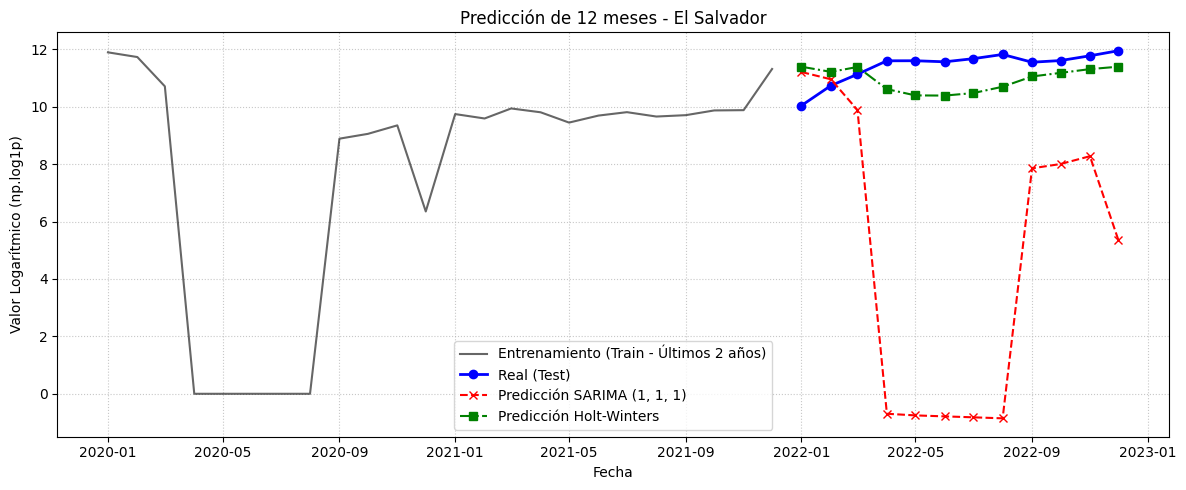


ANÁLISIS DE PRONÓSTICO PARA: Guatemala
Métricas en el conjunto de prueba (Test):
 - SARIMA -> RMSE: 2.0418 | MAE: 1.8967
 - Holt-W -> RMSE: 1.0987 | MAE: 1.0472


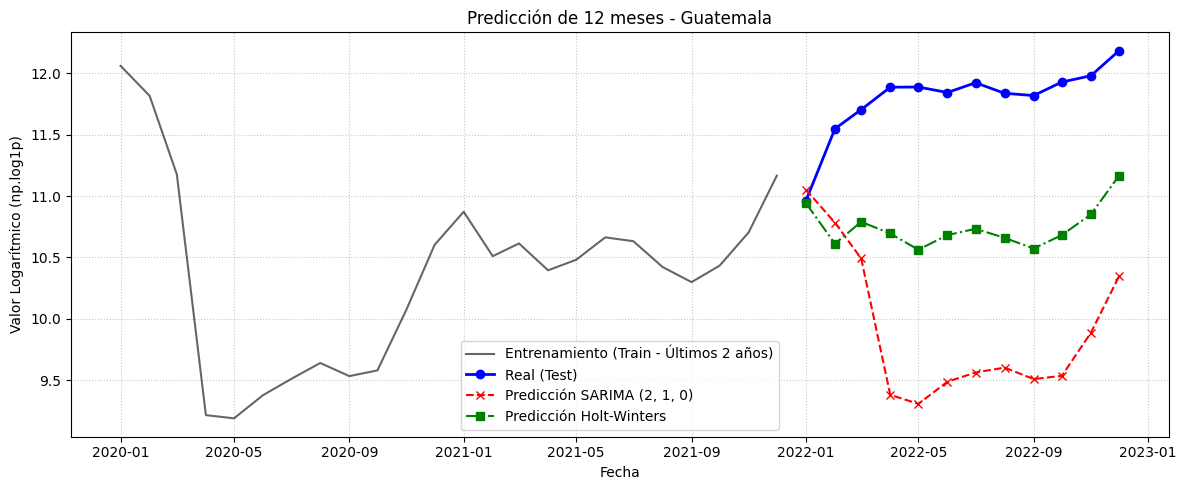


ANÁLISIS DE PRONÓSTICO PARA: Estados Unidos de América
Métricas en el conjunto de prueba (Test):
 - SARIMA -> RMSE: 7.2625 | MAE: 5.3917
 - Holt-W -> RMSE: 0.4983 | MAE: 0.4179


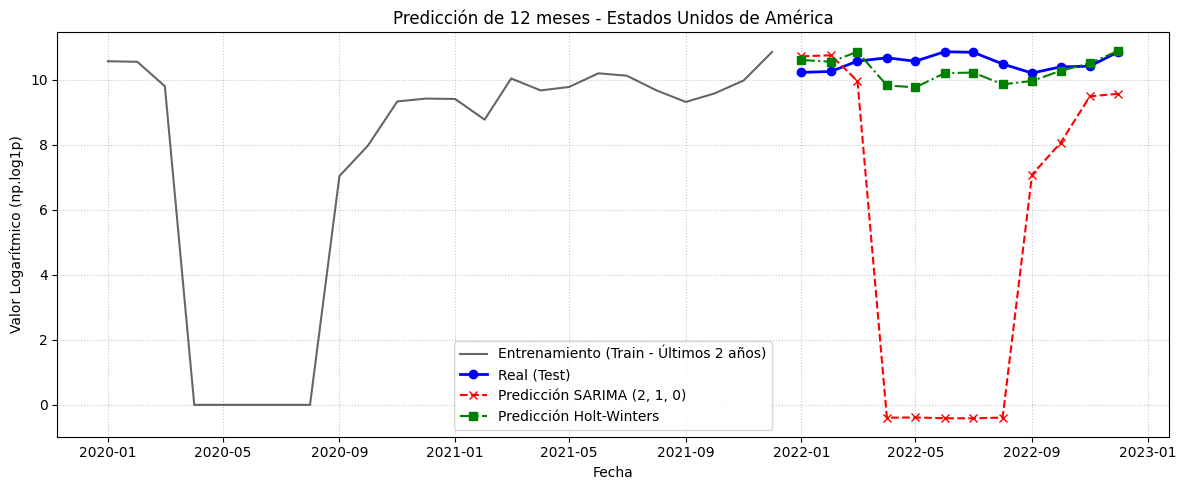

In [42]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

print("--- PREDICCIÓN SOBRE EL CONJUNTO DE PRUEBA (SARIMA vs HOLT-WINTERS) ---")

for pais, serie_log in series_paises_transformadas.items():
    print(f"\n========================================")
    print(f"ANÁLISIS DE PRONÓSTICO PARA: {pais}")
    print(f"========================================")
    
    # 80-90% train 
    train = serie_log.iloc[:-12]
    test = serie_log.iloc[-12:]
    
    
    order_sarima = (1, 1, 1) if pais == 'El Salvador' else (2, 1, 0)
    
    modelo_sarima = SARIMAX(
        train, 
        order=order_sarima, 
        seasonal_order=(1, 1, 1, 12), 
        enforce_stationarity=False, 
        enforce_invertibility=False
    ).fit(disp=False, maxiter=200)
    
    pred_sarima = modelo_sarima.forecast(steps=12)
    
    modelo_hw = ExponentialSmoothing(
        train, 
        trend='add', 
        seasonal='add', 
        seasonal_periods=12
    ).fit()
    
    pred_hw = modelo_hw.forecast(steps=12)
    
    # calcular errores de prueba (RMSE y MAE)
    print("Métricas en el conjunto de prueba (Test):")
    print(f" - SARIMA -> RMSE: {root_mean_squared_error(test, pred_sarima):.4f} | MAE: {mean_absolute_error(test, pred_sarima):.4f}")
    print(f" - Holt-W -> RMSE: {root_mean_squared_error(test, pred_hw):.4f} | MAE: {mean_absolute_error(test, pred_hw):.4f}")
    
    #graficas
    plt.figure(figsize=(12, 5))
    plt.plot(train.index[-24:], train.iloc[-24:], label='Entrenamiento (Train - Últimos 2 años)', color='black', alpha=0.6)
    plt.plot(test.index, test, label='Real (Test)', color='blue', marker='o', linewidth=2)
    plt.plot(test.index, pred_sarima, label=f'Predicción SARIMA {order_sarima}', color='red', linestyle='--', marker='x')
    plt.plot(test.index, pred_hw, label='Predicción Holt-Winters', color='green', linestyle='-.', marker='s')
    
    plt.title(f'Predicción de 12 meses - {pais}')
    plt.xlabel('Fecha')
    plt.ylabel('Valor Logarítmico (np.log1p)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

### Comparación mediante MAE, RMSE, AIC, y BIC

In [45]:
import pandas as pd
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

print("--- TABLA COMPARATIVA FINAL: MAE, RMSE, AIC y BIC ---")

resultados_finales = {}

for pais, serie_log in series_paises_transformadas.items():
    train = serie_log.iloc[:-12]
    test = serie_log.iloc[-12:]
    
    order_sarima = (1, 1, 1) if pais == 'El Salvador' else (2, 1, 0)
    
    modelo_sarima = SARIMAX(
        train, 
        order=order_sarima, 
        seasonal_order=(1, 1, 1, 12), 
        enforce_stationarity=False, 
        enforce_invertibility=False
    ).fit(disp=False, maxiter=200)
    pred_sarima = modelo_sarima.forecast(steps=12)
    
    modelo_hw = ExponentialSmoothing(
        train, 
        trend='add', 
        seasonal='add', 
        seasonal_periods=12
    ).fit()
    pred_hw = modelo_hw.forecast(steps=12)
    
    tabla_comparativa = pd.DataFrame({
        'SARIMA': [
            root_mean_squared_error(test, pred_sarima),
            mean_absolute_error(test, pred_sarima),
            modelo_sarima.aic,
            modelo_sarima.bic
        ],
        'Holt-Winters': [
            root_mean_squared_error(test, pred_hw),
            mean_absolute_error(test, pred_hw),
            float('nan'), # AIC no aplica directamente en HW 
            float('nan')  # BIC no aplica directamente en HW
        ]
    }, index=['RMSE', 'MAE', 'AIC', 'BIC'])
    
    print(f"\n========================================")
    print(f"RESUMEN COMPARATIVO PARA: {pais}")
    print(f"========================================")
    print(tabla_comparativa.round(4).to_string())

--- TABLA COMPARATIVA FINAL: MAE, RMSE, AIC y BIC ---

RESUMEN COMPARATIVO PARA: El Salvador
        SARIMA  Holt-Winters
RMSE    8.4607        0.8945
MAE     6.8519        0.8107
AIC   445.6932           NaN
BIC   459.9922           NaN

RESUMEN COMPARATIVO PARA: Guatemala
      SARIMA  Holt-Winters
RMSE  2.0418        1.0987
MAE   1.8967        1.0472
AIC  -5.1986           NaN
BIC   9.1005           NaN

RESUMEN COMPARATIVO PARA: Estados Unidos de América
        SARIMA  Holt-Winters
RMSE    7.2625        0.4983
MAE     5.3917        0.4179
AIC   393.5851           NaN
BIC   407.8842           NaN
